# Word Embedding Evaluation & Analysis

With embeddings trained pretrained, this notebook evaluates and explores the resulting vector space.

Evaluation is split into two parts:

- **Embedding Analysis** — qualitative and visual exploration of the embedding space: nearest neighbour queries, analogy probing, and t-SNE visualisation.
- **Intrinsic Evaluation** — benchmarking against [WordSim353](https://gabrilovich.com/resources/data/wordsim353/wordsim353.html), a dataset of word pairs with human-assigned similarity scores. The cosine similarities are measured how well they correlate with human judgement using Spearman's rank correlation.

## Notebook Structure

1. **Setup** — loading the pre-trained embeddings from `artefacts/`
2. **t-SNE Visualisation** — projecting the embedding space down to 2D
3. **Nearest Neighbours** — querying the most semantically similar words
4. **Analogy Probing** — testing relational structure in the embedding space
5. **WordSim353 Benchmark** — Spearman correlation against human similarity judgements  

In [1]:
import numpy as np
import json

# Load embeddings
data = np.load("../artefacts/skipgram_embeddings.npz")
W = data["W"]

with open("../artefacts/word_idx.json", "r") as f:
    word_idx = json.load(f)

with open("../artefacts/idx_word.json", "r") as f:
    idx_word = json.load(f)

# IMPORTANT: JSON turns keys into strings
idx_word = {int(k): v for k, v in idx_word.items()}

In [4]:
import numpy as np
import json

# Load embeddings
data = np.load("../artefacts/filtered_embeddings.npz")
W = data["W"]

with open("../artefacts/filtered_word_idx.json", "r") as f:
    word_idx = json.load(f)

with open("../artefacts/filtered_idx_word.json", "r") as f:
    idx_word = json.load(f)

# IMPORTANT: JSON turns keys into strings
idx_word = {int(k): v for k, v in idx_word.items()}

### Visualising Word Embeddings (t-SNE)

To inspect the learned embeddings, t-SNE is used to reduce the 100-dimensional vectors into 2D for plotting. This allows a qualitative view of how words cluster after training.

A small subset of words is selected from the vocabulary, and their corresponding embeddings are projected into two dimensions using t-SNE. Words that appear in similar contexts tend to form visible clusters, giving a rough indication of whether the model has captured meaningful structure.

Each point is then plotted and labelled with its corresponding word for interpretation.

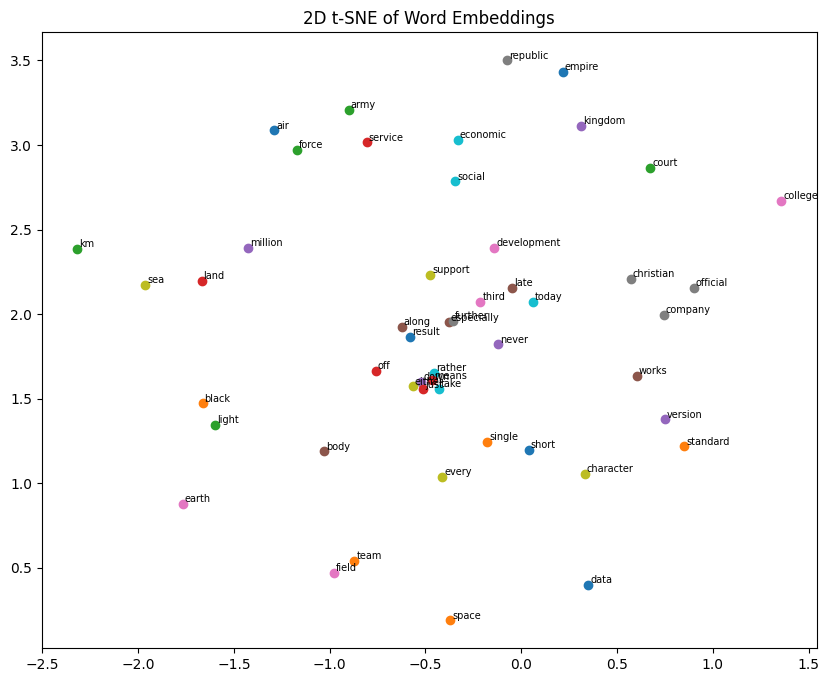

In [5]:
from utils import plot_embeddings_for_words

words = list(word_idx.keys())[200:250]
plot_embeddings_for_words(words, W, word_idx, idx_word, seed=17)

### Finding Similar Words (Cosine Similarity)

To evaluate the learned embeddings, similarity between words is computed using **cosine similarity**, which measures the angle between two vectors rather than their raw magnitude.

For two word vectors $x$ and $y$, similarity is defined as:

$
\cos(\theta) = \frac{x \cdot y}{\|x\| \|y\|}
$

A higher value indicates stronger semantic or contextual similarity.

Distance is then expressed as:
$
\text{distance} = 1 - \cos(\theta)
$

For a given query word, words are ranked by similarity score.

In [14]:
from utils import most_similar

word_relations = ["book"]

for word in word_relations:
    print(f'{word.upper():<12} | Similar Word       | Cosine Distance')
    print('-' * 50)

    for w, dist in most_similar(word, word_idx, idx_word, W, top_n=10):
        print(f'{"":<12} | {w:<18} | {dist:.4f}')

    print()

BOOK         | Similar Word       | Cosine Distance
--------------------------------------------------
             | abridgement        | 0.2650
             | story              | 0.3155
             | abridgment         | 0.3273
             | kabbala            | 0.3296
             | catena             | 0.3301
             | denouement         | 0.3318
             | acrostic           | 0.3350
             | perusal            | 0.3370
             | scrivener          | 0.3412
             | prophetically      | 0.3434



### Word Analogies (Vector Arithmetic)

Word embeddings capture semantic relationships that can be explored through **vector arithmetic**. If the embedding space has learned meaningful structure, analogical relationships manifest as consistent **directional offsets** between word vectors.

Given three words, the goal is to find a fourth word $w^*$ that completes the relationship $w_1 : w_2 \approx w_3 : w^*$:

$$w^* = \vec{w}_3 - \vec{w}_1 + \vec{w}_2$$

The candidate $w^*$ is identified as the word whose vector lies closest (by cosine similarity) to the computed target vector, excluding the three query words from the results.

The benchmark example from Mikolov et al. (2013) is:

$$\text{king} - \text{man} + \text{woman} \approx \text{queen}$$

This suggests the model has encoded a **gender offset** as a consistent direction in the embedding space. Well-trained embeddings tend to capture a range of such structural relationships, including:

- **Gender**: *king → queen*, *actor → actress*
- **Plurality**: *cat → cats*, *city → cities*
- **Verb tense**: *walk → walked*, *run → ran*
- **Country–capital**: *France → Paris*, *Germany → Berlin*
- **Comparative degree**: *good → better*, *big → bigger*

In [16]:
from utils import analogy

# run the classic example
results = analogy("king", "man", "woman", W, word_idx, idx_word)

for w, score in results:
    print(f"{w:<15} {score:.4f}")

betrothed       0.5861
queen           0.5780
prince          0.5721
apportion       0.5716
besiege         0.5633
homonymous      0.5632
daughter        0.5601
harem           0.5585
archduchess     0.5574
magnanimous     0.5567


### Quantitative Evaluation: WordSim-353

To evaluate the embeddings more rigorously, the model's cosine similarity scores are compared against human judgement using the **WordSim-353** benchmark dataset. This is a standard NLP evaluation set comprising 353 word pairs, each annotated with a human similarity rating on a scale of 0 to 10.

For each word pair in WordSim-353, the model's cosine similarity is computed and rescaled to the same 0–10 range as the human ratings, allowing direct comparison. A sample of pairs is displayed below.

In [17]:
import random
from utils import word_similarity
import pandas as pd 

wordsim = pd.read_csv("../data/combined.csv")

score1_list = []
score2_list = []
all_results = []

pairs = list(zip(wordsim.iloc[:, 0], wordsim.iloc[:, 1]))

for i, word in enumerate(pairs):
    score1 = word_similarity(word[0].lower(), word[1].lower(), word_idx, W)
    score2 = wordsim.iloc[i, 2]

    if score1 is None:
        continue

    if score1 > 0:
        score1 = score1 ** 0.5

    score1 *= 10

    score1_list.append(score1)
    score2_list.append(score2)
    all_results.append((word[0], word[1], score1, score2))

# Sample 10 random entries for display only
sample = random.sample(all_results, 10)

print(f"{'Word 1':<15} {'Word 2':<15} {'Predicted':>10} {'Actual':>10}")
print("-" * 52)
for w1, w2, s1, s2 in sample:
    print(f"{w1:<15} {w2:<15} {s1:>10.2f} {s2:>10.2f}")

Word 1          Word 2           Predicted     Actual
----------------------------------------------------
glass           metal                 7.35       5.56
cup             article               5.33       2.40
competition     price                 6.24       6.44
book            paper                 6.84       7.46
death           row                   5.27       5.25
glass           magician              5.51       2.08
dividend        payment               7.01       7.63
day             summer                7.08       3.94
tiger           zoo                   6.49       5.87
network         hardware              7.46       8.31


### Correlation Analysis

To quantify alignment between the model's predictions and human ratings, two correlation metrics are computed:

- **Pearson correlation** measures the strength of the *linear* relationship between the two score distributions.
- **Spearman correlation** measures *rank-order* agreement, making it more robust to outliers and non-linear scaling. It is the more commonly reported metric for WordSim-353 benchmarking.

In [18]:
from scipy.stats import pearsonr, spearmanr

pearson_corr, _  = pearsonr(score1_list, score2_list)
spearman_corr, _ = spearmanr(score1_list, score2_list)

print(f"\n{'Pearson correlation:':<25} {pearson_corr:.4f}")
print(f"{'Spearman correlation:':<25} {spearman_corr:.4f}")


Pearson correlation:      0.6279
Spearman correlation:     0.6217
